In [1]:
import os
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
import keyring
from io import StringIO
import requests
from matplotlib.ticker import FuncFormatter, MaxNLocator

import eikon as ek
from pydatastream import Datastream

from scipy.stats import ttest_ind, ttest_ind_from_stats
from scipy.special import stdtr

# Connection to Datastream

In [2]:
# --- Log ind ---
ek.set_app_key('035d2f1682244553ba7f239ce9e8d281142013dd')
service = "Datastream"
DS_USERNAME = "ZNYK749" #Ændre denne
DS_PASSWORD = keyring.get_password(service, DS_USERNAME)

if DS_USERNAME and DS_PASSWORD:
    DS = Datastream(username=DS_USERNAME, password=DS_PASSWORD)
else:
    DS = None
    print("WARNING: DS_USERNAME/DS_PASSWORD ikke sat som miljøvariabler.")

# Dates

In [29]:
pd.set_option('display.max_rows', 10)
#GICS data dates
start_gics = '20160901'
end_gics = datetime.today().strftime('%Y%m%d') #Sætter automatisk til dags dato
start_ds_gics = start_gics
end_ds_gics = end_gics

#Futures data dates
start = '20060915'
end = datetime.today().strftime('%Y%m%d')  # Sætter automatisk til dags dato
start_ds = start
end_ds = end

source = 'datastream'
fx = 'DKK'
width_bar = 1

N = 1
ind = np.arange(N)

# MSCI GICS sectors

In [30]:
def fetch_and_rename_data(symbol, column_name):
    data = DS.get_price([symbol], date_from=start_ds_gics, date_to=end_ds_gics)
    data = data.rename(columns={'P': column_name})
    return data

gics_sectors = [
    ('M1AFCS$(MSNR)~DKK', 'Consumer Staples'),
    ('M1AFID$(MSNR)~DKK', 'Industrials'),
    ('M1AFHC$(MSNR)~DKK', 'Health Care'),
    ('M1AFM1$(MSNR)~DKK', 'Materials'),
    ('M1AFIT$(MSNR)~DKK', 'IT'),
    ('M1AFFN$(MSNR)~DKK', 'Financials'),
    ('M1AFCD$(MSNR)~DKK', 'Consumer Discretionary'),
    ('M1AFE1$(MSNR)~DKK', 'Energy'),
    ('M1AFR1$(MSNR)~DKK', 'Real Estate'),
    ('M1AFU1$(MSNR)~DKK', 'Utilities'),
    ('M1AFT1$(MSNR)~DKK', 'Communication Services'),
]

gics_data = None

for symbol, column_name in gics_sectors:
    series = fetch_and_rename_data(symbol, column_name)
    gics_data = series if gics_data is None else pd.merge(
        gics_data, series, left_index=True, right_index=True, how='outer')

#print(gics_data.head())
#print(gics_data.shape)

Regner returns & Eksportere til CSV

In [31]:
#Print GICS sector data to csv in the data folder
gics_data.to_csv('data/gics_sector_data.csv')
# Calculate returns and export to CSV
gics_returns = gics_data.pct_change()
gics_returns.to_csv('data/gics_sector_returns.csv')

### Plot data og tjek for outliers

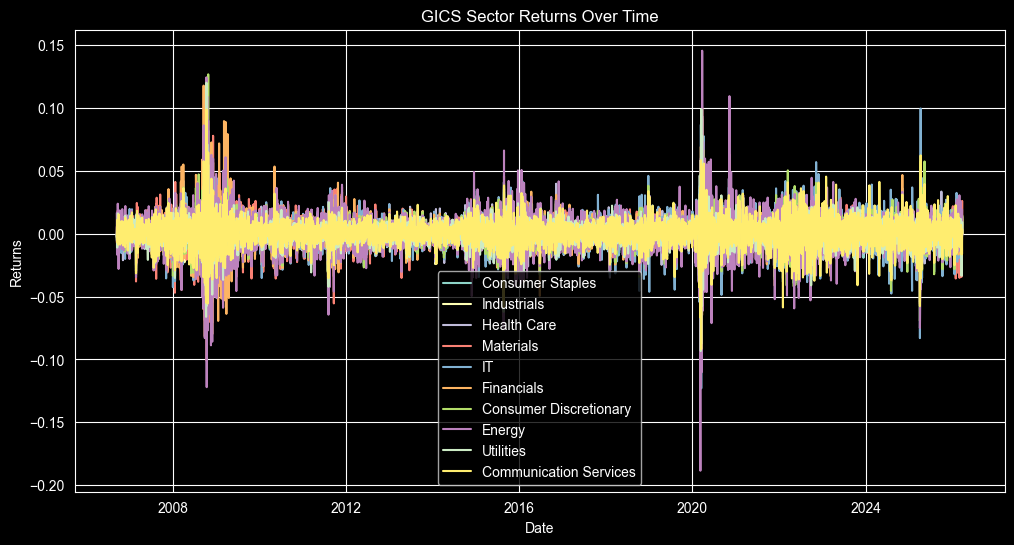

In [25]:
#Plot returns
plt.figure(figsize=(12, 6))
for column in gics_returns.columns:
    plt.plot(gics_returns.index, gics_returns[column], label=column)
plt.title('GICS Sector Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

Tjek for outliers

In [26]:
#Tjek for outliers
threshold = 0.15  # 15% dagligt afkast er ekstremt for sektorer
outliers = gics_returns[gics_returns.abs() > threshold]
print(outliers.stack().dropna().sort_values(ascending=False))

2020-03-09  Energy   -0.188452
dtype: float64


# Futures

### Henter med "P" først, og hvis det fejler, så prøver vi "PO", og hvis det også fejler, så "PS"

In [13]:
def clean_price_series(data, column_name, jump_threshold=2.0):
    """
    Detekterer og back-adjusterer kontraktskift-fejl i en prisserie.

    jump_threshold: Faktor hvor et prisjump anses som fejl (default: 2x = 200% ændring).
    Reelle daglige futures-afkast overstiger aldrig denne faktor.
    """
    series = data[column_name].copy()

    # Beregn daglige prisratioer (ikke afkast, men faktorer)
    ratios = series / series.shift(1)

    # Find datoer hvor prisen hopper mere end threshold i begge retninger
    jump_dates = series.index[
        (ratios > jump_threshold) | (ratios < 1 / jump_threshold)
    ]

    if len(jump_dates) == 0:
        return data  # Ingen fejl fundet

    for jump_date in jump_dates:
        factor = ratios.loc[jump_date]
        print(f"  ⚠ Kontraktskift detekteret i '{column_name}' på {jump_date.date()}: "
              f"prisjump faktor {factor:.2f}x — back-adjusterer historik")

        # Juster alle tidligere priser med samme faktor så serien bliver kontinuert
        series.loc[series.index < jump_date] *= factor

    data = data.copy()
    data[column_name] = series
    return data


def fetch_futures_data(symbol, column_name, fields_to_try=None):
    if fields_to_try is None:
        fields_to_try = ['P', 'PO', 'PS']

    for field in fields_to_try:
        try:
            data = DS.fetch(symbol, fields=field,
                            date_from=start_ds, date_to=end_ds, freq='D')

            if data is not None and not data.empty and data.iloc[:, 0].notna().any():
                data = data.rename(columns={field: column_name})
                data = clean_price_series(data, column_name)  # <-- Clean lige efter fetch
                print(f"✓ {column_name} ({symbol}) hentet med felt '{field}'")
                return data
            else:
                print(f"  → {symbol} med felt '{field}' returnerede tom/NaN data, prøver næste...")

        except Exception as e:
            print(f"  → {symbol} med felt '{field}' fejlede: {e}, prøver næste...")

    print(f"✗ {column_name} ({symbol}) kunne ikke hentes med nogen af felterne: {fields_to_try}")
    return None

# Definer futures med valgfri field-override
equity_futures = [
    ('ISMCS00', 'S&P 500'),
    ('CENCS00', 'NASDAQ 100'),
    ('GEXCS00', 'Euro Stoxx 50'),
    ('ONACS00', 'Nikkei 225'),       # Vil automatisk falde tilbage til PS/PO
    ('SCNCS00', 'FTSE China A50'),   # Vil automatisk falde tilbage til PS/PO
    ('GDXCS00', 'DAX'),
    ('HSICS00', 'Hang Seng', ['PS', 'P']),
    ('LSXCS00', 'FTSE 100'),
    #('BSXCS00', 'India')
]

bond_futures = [
    ('GGECS00', 'EURO BUND 10Y'),
    ('GBECS00', 'EURO BOBL 5Y'),
    ('GEBCS00', 'EURO SCHATZ 2Y'),
    ('CTTCS00', 'US T-Note 10Y'),
    ('CTFCS00', 'US T-Note 5Y'),
    ('CTECS00', 'US T-Note 2Y')
]

# Bonds bruger kun 'P' — ingen grund til at prøve andre fields
futures_data = None

for item in equity_futures:
    symbol, column_name = item[0], item[1]
    fields = item[2] if len(item) > 2 else ['P', 'PS', 'PO']

    series = fetch_futures_data(symbol, column_name, fields_to_try=fields)
    if series is not None:
        futures_data = series if futures_data is None else pd.merge(
            futures_data, series, left_index=True, right_index=True, how='outer')

for symbol, column_name in bond_futures:
    series = fetch_futures_data(symbol, column_name, fields_to_try=['P'])
    if series is not None:
        futures_data = series if futures_data is None else pd.merge(
            futures_data, series, left_index=True, right_index=True, how='outer')

✓ S&P 500 (ISMCS00) hentet med felt 'P'
✓ NASDAQ 100 (CENCS00) hentet med felt 'P'
✓ Euro Stoxx 50 (GEXCS00) hentet med felt 'P'
  → ONACS00 med felt 'P' fejlede: "ONACS00"("P"): $$ER: E100,INVALID CODE OR EXPRESSION ENTERED, prøver næste...
✓ Nikkei 225 (ONACS00) hentet med felt 'PS'
  → SCNCS00 med felt 'P' fejlede: "SCNCS00"("P"): $$ER: E100,INVALID CODE OR EXPRESSION ENTERED, prøver næste...
✓ FTSE China A50 (SCNCS00) hentet med felt 'PS'
✓ DAX (GDXCS00) hentet med felt 'P'
✓ Hang Seng (HSICS00) hentet med felt 'PS'
✓ FTSE 100 (LSXCS00) hentet med felt 'P'
✓ EURO BUND 10Y (GGECS00) hentet med felt 'P'
✓ EURO BOBL 5Y (GBECS00) hentet med felt 'P'
✓ EURO SCHATZ 2Y (GEBCS00) hentet med felt 'P'
✓ US T-Note 10Y (CTTCS00) hentet med felt 'P'
✓ US T-Note 5Y (CTFCS00) hentet med felt 'P'
✓ US T-Note 2Y (CTECS00) hentet med felt 'P'


Regner returns & Eksportere til CSV

In [14]:
#Write the futures data to a CSV file
futures_data.to_csv('data/futures_data.csv')
# Beregner returns
future_returns = futures_data.pct_change()
# Eksporter returns til CSV i data mappen
future_returns.to_csv('data/futures_returns.csv')

### Plot data og tjek for outliers

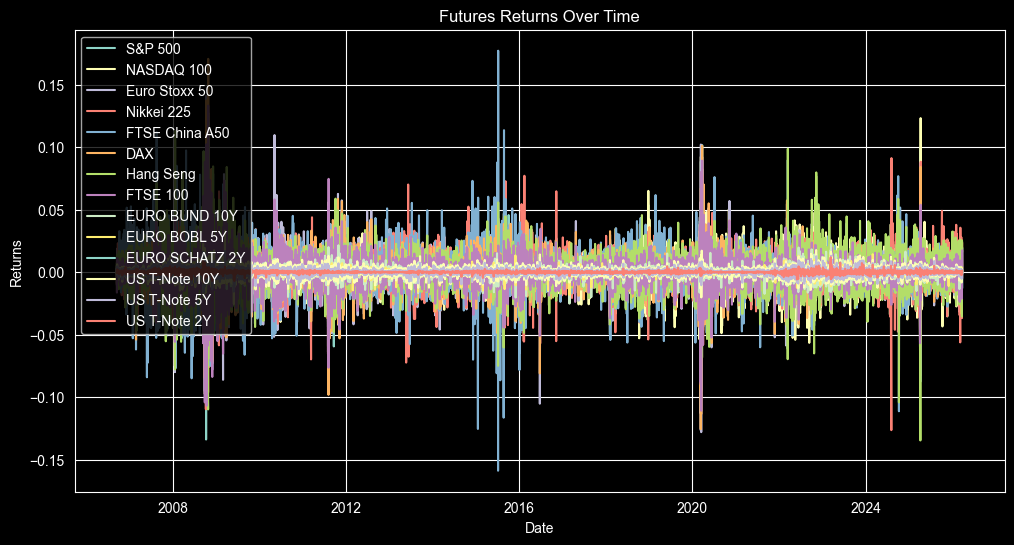

In [16]:
#Plot returns
plt.figure(figsize=(12, 6))
for column in future_returns.columns:
    plt.plot(future_returns.index, future_returns[column], label=column)
plt.title('Futures Returns Over Time')
plt.xlabel('Date')
plt.ylabel('Returns')
plt.legend()
plt.show()

In [17]:
# Se de værste outliers
threshold = 0.15  # 15% dagligt afkast er ekstremt for futures
outliers = future_returns[future_returns.abs() > threshold]
print(outliers.stack().dropna().sort_values(ascending=False))

2015-07-09  FTSE China A50    0.177018
2008-10-28  DAX               0.170536
2015-07-08  FTSE China A50   -0.158841
dtype: float64
